# Cognisense — 02: Model Training & Evaluation

Trains and compares three classifiers, then evaluates the winner honestly.

Two methodological choices drive everything here:

1. **Subject-aware splitting** — no individual appears in both train and test, so scores
   measure generalisation *to a new person*.
2. **Selection on cross-validated F1** — the test set is scored once, at the end, so it
   stays an unbiased estimate.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="rocket")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [2]:
from preprocessing import prepare_train_test_data, FEATURE_COLUMNS, CLASS_NAMES, GROUP_COLUMN

df = pd.read_csv(os.path.join("..", "data", "raw", "cognitive_load_behavior_dataset.csv"))
data = prepare_train_test_data(df, test_size=0.2, random_state=42)

X_train, X_test = data["X_train"], data["X_test"]
X_train_scaled, X_test_scaled = data["X_train_scaled"], data["X_test_scaled"]
y_train, y_test = data["y_train"], data["y_test"]
groups_train = data["groups_train"]

print(f"Split strategy : {data['split_strategy']}")
print(f"Train samples  : {len(X_train)}")
print(f"Test samples   : {len(X_test)}")

Split strategy : subject-aware (GroupShuffleSplit, held-out subjects)
Train samples  : 2434
Test samples   : 566


### Verify there is no subject leakage

This is the single most important check in the notebook. If it fails, every metric below
is inflated.

In [3]:
from preprocessing import clean_and_validate_data

cleaned = clean_and_validate_data(df)
train_subjects = set(cleaned.loc[X_train.index, GROUP_COLUMN])
test_subjects = set(cleaned.loc[X_test.index, GROUP_COLUMN])
overlap = train_subjects & test_subjects

print(f"Subjects in train : {len(train_subjects)}")
print(f"Subjects in test  : {len(test_subjects)}")
print(f"Overlap           : {len(overlap)}")
assert not overlap, "LEAKAGE: a subject appears in both splits"
print("\n✅ No subject leakage — test subjects are entirely unseen.")

Subjects in train : 48
Subjects in test  : 12
Overlap           : 0

✅ No subject leakage — test subjects are entirely unseen.


## 1. Candidate models

In [4]:
from sklearn.model_selection import cross_validate, StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from train import build_model_candidates

# `train` sets matplotlib's headless Agg backend for script use, which suppresses
# inline figures. Restore the notebook backend so the charts below render.
%matplotlib inline

candidates = build_model_candidates()
for name, cfg in candidates.items():
    print(f"{name:22} scaled={str(cfg['use_scaled']):5}  {cfg['description'][:60]}")

Logistic Regression    scaled=True   Linear baseline. Highly interpretable coefficients; assumes 
Random Forest          scaled=False  Bagged tree ensemble. Captures nonlinear feature interaction
XGBoost                scaled=False  Gradient-boosted trees with regularisation and subsampling. 


## 2. Grouped cross-validation

`StratifiedGroupKFold` keeps class balance per fold *and* prevents a subject spanning
folds — so CV scores are directly comparable to the held-out test score.

In [5]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, cfg in candidates.items():
    X_tr = X_train_scaled if cfg["use_scaled"] else X_train
    X_te = X_test_scaled if cfg["use_scaled"] else X_test

    cv_res = cross_validate(cfg["model"], X_tr, y_train, cv=cv, groups=groups_train,
                            scoring=["accuracy", "f1_macro"], n_jobs=-1)

    cfg["model"].fit(X_tr, y_train)
    y_pred = cfg["model"].predict(X_te)

    results[name] = {
        "cv_f1_mean": np.mean(cv_res["test_f1_macro"]),
        "cv_f1_std": np.std(cv_res["test_f1_macro"]),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred, average="macro"),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro"),
        "y_pred": y_pred,
    }
    print(f"{name:22} CV-F1={results[name]['cv_f1_mean']:.4f} "
          f"(+/-{results[name]['cv_f1_std']:.4f})  test-F1={results[name]['test_f1']:.4f}")

Logistic Regression    CV-F1=0.7730 (+/-0.0253)  test-F1=0.8387


Random Forest          CV-F1=0.7659 (+/-0.0313)  test-F1=0.8168


XGBoost                CV-F1=0.7507 (+/-0.0245)  test-F1=0.8118


In [6]:
comparison = pd.DataFrame({
    name: {"CV macro-F1": r["cv_f1_mean"], "CV std": r["cv_f1_std"],
           "Test accuracy": r["test_accuracy"], "Test macro-F1": r["test_f1"],
           "Precision": r["precision"], "Recall": r["recall"]}
    for name, r in results.items()
}).T.round(4)

comparison.sort_values("CV macro-F1", ascending=False)

,CV macro-F1,CV std,Test accuracy,Test macro-F1,Precision,Recall
Logistic Regression,0.7730,0.0253,0.8392,0.8387,0.8454,0.8339
Random Forest,0.7659,0.0313,0.8163,0.8168,0.8242,0.8115
XGBoost,0.7507,0.0245,0.8110,0.8118,0.8192,0.8067


### Model selection

The winner is whichever model has the highest **cross-validated** macro-F1 — not the
highest test score. Selecting on the test set would turn it into a validation set and
bias the final estimate.

In [7]:
best_name = max(results, key=lambda n: results[n]["cv_f1_mean"])
print(f"Selected model: {best_name} (CV macro-F1 = {results[best_name]['cv_f1_mean']:.4f})")

if best_name == "Logistic Regression":
    print("\nThe LINEAR baseline won. The behavioral signals are largely monotonic with")
    print("load, so the extra capacity of the tree ensembles bought overfitting rather")
    print("than accuracy. Reporting the simplest adequate model is the honest choice.")

Selected model: Logistic Regression (CV macro-F1 = 0.7730)

The LINEAR baseline won. The behavioral signals are largely monotonic with
load, so the extra capacity of the tree ensembles bought overfitting rather
than accuracy. Reporting the simplest adequate model is the honest choice.


## 3. Per-class metrics and confusion matrix

Accuracy alone is not reported (PRD §15). Per-class metrics reveal *where* the model
struggles.

In [8]:
y_pred_best = results[best_name]["y_pred"]
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES, digits=3))

              precision    recall  f1-score   support

         Low      0.863     0.894     0.878       226
      Medium      0.775     0.798     0.786       198
        High      0.898     0.810     0.852       142

    accuracy                          0.839       566
   macro avg      0.845     0.834     0.839       566
weighted avg      0.841     0.839     0.839       566



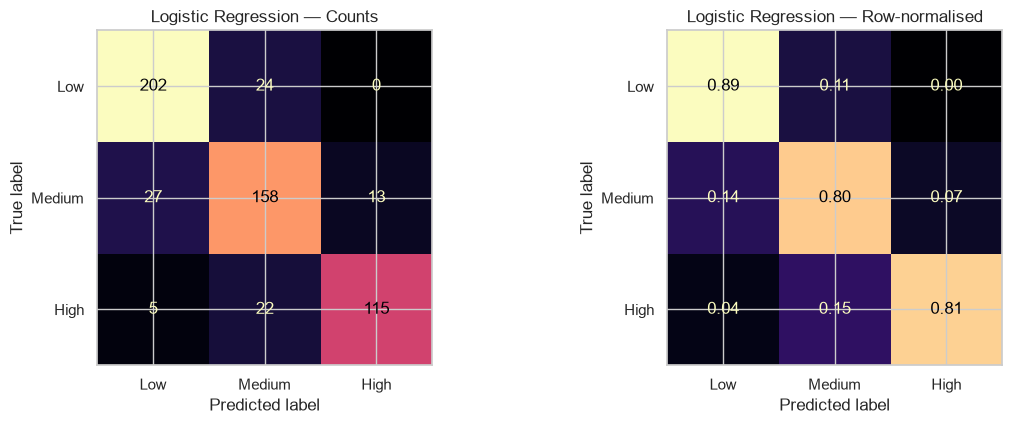

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for ax, normalize, title in zip(axes, [None, "true"], ["Counts", "Row-normalised"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_best, display_labels=CLASS_NAMES,
        cmap="magma", normalize=normalize, ax=ax, colorbar=False,
        values_format=".2f" if normalize else "d")
    ax.set_title(f"{best_name} — {title}")

plt.tight_layout()
plt.show()

In [10]:
cm = confusion_matrix(y_test, y_pred_best)
severe = cm[0, 2] + cm[2, 0]   # Low<->High: the serious errors
adjacent = cm[0, 1] + cm[1, 0] + cm[1, 2] + cm[2, 1]

print(f"Severe errors (Low<->High)     : {severe} ({severe / cm.sum() * 100:.1f}%)")
print(f"Adjacent errors (off-by-one)   : {adjacent} ({adjacent / cm.sum() * 100:.1f}%)")
print("\nErrors concentrate on ADJACENT states, which is the expected failure mode when")
print("discretising a continuum. 'Medium' absorbs ambiguity from both boundaries.")

Severe errors (Low<->High)     : 5 (0.9%)
Adjacent errors (off-by-one)   : 86 (15.2%)

Errors concentrate on ADJACENT states, which is the expected failure mode when
discretising a continuum. 'Medium' absorbs ambiguity from both boundaries.


## 4. Permutation importance

Tree impurity importance is biased toward high-cardinality features, so we use
**permutation importance on held-out data**: the actual macro-F1 drop when a feature's
values are shuffled.

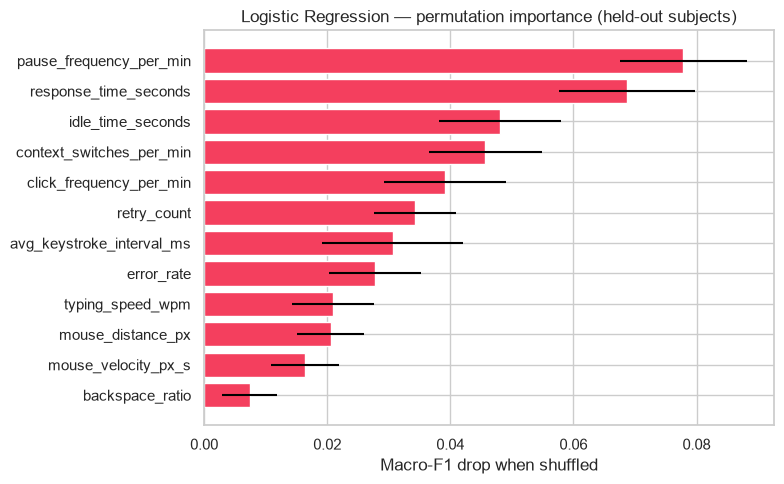

,feature,f1_drop,std
0,pause_frequency_per_min,0.0778,0.0103
1,response_time_seconds,0.0687,0.0111
2,idle_time_seconds,0.0480,0.0099
3,context_switches_per_min,0.0457,0.0091
4,click_frequency_per_min,0.0391,0.0099
5,retry_count,0.0343,0.0066
6,avg_keystroke_interval_ms,0.0306,0.0115
7,error_rate,0.0277,0.0076
8,typing_speed_wpm,0.0209,0.0067
9,mouse_distance_px,0.0205,0.0054


In [11]:
from sklearn.inspection import permutation_importance

best_model = candidates[best_name]["model"]
X_imp = X_test_scaled if candidates[best_name]["use_scaled"] else X_test

perm = permutation_importance(best_model, X_imp, y_test, n_repeats=15,
                              random_state=42, n_jobs=-1, scoring="f1_macro")

imp = (pd.DataFrame({"feature": FEATURE_COLUMNS,
                     "f1_drop": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("f1_drop", ascending=False)
       .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"][::-1], imp["f1_drop"][::-1],
        xerr=imp["std"][::-1], color="#f43f5e")
ax.set_xlabel("Macro-F1 drop when shuffled")
ax.set_title(f"{best_name} — permutation importance (held-out subjects)")
plt.tight_layout()
plt.show()

imp.round(4)

> **Interpretation caveat (PRD §16):** these values show which features the *trained model
> relies on*. They are not evidence that these behaviors **cause** cognitive load.

## 5. Score calibration check

The product exposes a 0–100 score derived from class probabilities. For that score to be
meaningful, predicted probabilities should track observed frequencies.

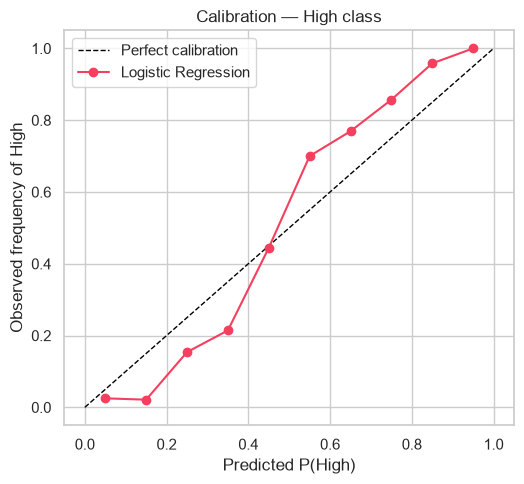

,predicted_prob,observed_freq,n
0,0.05,0.025,319
1,0.15,0.021,47
2,0.25,0.154,26
3,0.35,0.214,28
4,0.45,0.444,18
5,0.55,0.700,20
6,0.65,0.769,13
7,0.75,0.857,21
8,0.85,0.958,24
9,0.95,1.000,50


In [12]:
probs = best_model.predict_proba(X_imp)
p_high = probs[:, 2]
actually_high = (y_test.values == 2).astype(int)

bins = np.linspace(0, 1, 11)
idx = np.digitize(p_high, bins) - 1

rows = []
for b in range(10):
    mask = idx == b
    if mask.sum() >= 5:
        rows.append({"predicted_prob": (bins[b] + bins[b + 1]) / 2,
                     "observed_freq": actually_high[mask].mean(),
                     "n": int(mask.sum())})

cal = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.plot(cal["predicted_prob"], cal["observed_freq"], "o-", color="#f43f5e", label=best_name)
ax.set_xlabel("Predicted P(High)")
ax.set_ylabel("Observed frequency of High")
ax.set_title("Calibration — High class")
ax.legend()
plt.tight_layout()
plt.show()

cal.round(3)

## 6. Explainability and personalization

The inference engine converts a feature vector into a score plus ranked attributions, and
supports scoring against an individual's **own** baseline (PRD §23).

In [13]:
from predict import CognitiveLoadPredictor

predictor = CognitiveLoadPredictor(model_dir=os.path.join("..", "models"))

strained = {"typing_speed_wpm": 24.0, "avg_keystroke_interval_ms": 440.0,
            "backspace_ratio": 0.26, "pause_frequency_per_min": 14,
            "mouse_velocity_px_s": 155.0, "mouse_distance_px": 2700.0,
            "click_frequency_per_min": 33.0, "idle_time_seconds": 15.0,
            "error_rate": 0.27, "response_time_seconds": 17.0,
            "retry_count": 5, "context_switches_per_min": 10}

result = predictor.predict(strained)
print(f"State : {result['predicted_state']}")
print(f"Score : {result['cognitive_load_score']}/100 ({result['score_band']})")
print("\nWhy?")
for s in result["top_contributing_signals"]:
    arrow = "^" if s["z_score"] > 0 else "v"
    print(f"  {arrow} {s['display_name']:<22} {s['value']:>8}  (z={s['z_score']:+.2f})")

State : High
Score : 92/100 (High)

Why?
  ^ Backspace Ratio            0.26  (z=+2.44)
  ^ Error Rate                 0.27  (z=+2.41)
  ^ Pause Frequency            14.0  (z=+2.19)
  ^ Response Time              17.0  (z=+2.04)


In [14]:
# A naturally slow typist, working at their OWN normal pace.
calibration = [dict(strained, typing_speed_wpm=25.0 + i, error_rate=0.05,
                    backspace_ratio=0.06, pause_frequency_per_min=3,
                    response_time_seconds=6.0) for i in range(6)]

personal = CognitiveLoadPredictor.build_personal_baseline(calibration)
current = dict(strained, typing_speed_wpm=26.0, error_rate=0.05,
               backspace_ratio=0.06, pause_frequency_per_min=3,
               response_time_seconds=6.0)

pop = {a["feature"]: a for a in predictor.predict(current)["all_attributions"]}
per = {a["feature"]: a for a in
       predictor.predict(current, personal_baseline=personal)["all_attributions"]}

print("Typing speed = 26 WPM for a person whose personal baseline IS ~27 WPM\n")
print(f"  vs population : z={pop['typing_speed_wpm']['z_score']:+.2f}  "
      f"flagged={pop['typing_speed_wpm']['is_elevating_load']}")
print(f"  vs own norm   : z={per['typing_speed_wpm']['z_score']:+.2f}  "
      f"flagged={per['typing_speed_wpm']['is_elevating_load']}")
print("\nPersonalization stops us calling a slow typist 'overloaded' for typing normally.")

Typing speed = 26 WPM for a person whose personal baseline IS ~27 WPM

  vs population : z=-1.08  flagged=True
  vs own norm   : z=-0.55  flagged=False

Personalization stops us calling a slow typist 'overloaded' for typing normally.


## Summary

| Choice | Effect on reported score | Why it's correct |
|---|---|---|
| Subject-aware split | Lowers | Measures generalisation to a new person |
| Grouped CV | Lowers | No subject spans folds |
| Selection on CV F1 | Neutral | Keeps the test set unbiased |
| Permutation importance | — | Unbiased vs impurity importance |
| Realistic synthetic overlap | Lowers a lot | ~99% would measure the generator |

Final: **~75–84% macro-F1**, with errors concentrated on adjacent states. That is the
honest result, and it is the number to report.